# 01 · Solve the paper's 5-node example and verify the solution

This notebook reproduces the preliminary experiment of Wakui, Sakai and Akamatsu (2023):
a 5-node, 6-link network with origin 1 and destinations 4 and 5, a 60-minute horizon with
$ds = 1$, and 320 users per destination departing as a triangular pulse over the first 30 minutes.

Steps:

1. build the network,
2. solve the route-choice DUE with the paper's time-decomposed algorithm (`solve_sequential`),
3. check the solution against the equilibrium **and** physical-consistency conditions with the
   solver-independent checker,
4. draw the paper's figures: cumulative curves at the bottlenecks (Fig. 2) and the route-choice
   equilibrium per OD pair (Figs. 3, 4).

In [1]:
import time

import numpy as np

from rcdue.networks import wakui_5node
from rcdue.one_to_many import check_sequential_result, solve_sequential
from rcdue.plotting import (
    apply_style,
    plot_cumulative_curves,
    plot_queue_delays,
    plot_route_equilibrium,
)

apply_style()

## 1. Network

In [2]:
net = wakui_5node()
print(
    f"nodes={net.n_nodes} links={net.n_links} T={net.T} dt={net.dt} total demand={net.total_demand():.0f}"
)
for link in net.links:
    print(
        f"  link {link.key}: free-flow time {link.tau_hat:5.1f}  capacity {link.mu_hat:5.1f}"
    )

nodes=5 links=6 T=60 dt=1.0 total demand=640
  link (1, 2): free-flow time   3.0  capacity   8.0
  link (1, 3): free-flow time  15.0  capacity  12.0
  link (2, 3): free-flow time   2.0  capacity   4.0
  link (2, 4): free-flow time   5.0  capacity   6.0
  link (3, 4): free-flow time  10.0  capacity   4.0
  link (3, 5): free-flow time   1.0  capacity   6.0


## 2. Solve

`backend="auto"` uses Gurobi when it is installed and licensed, otherwise HiGHS (scipy).
The result holds `w` (queue delay), `y` (link inflow rate) and `pi` (origin-to-node travel time),
each indexed by link (or node) and **departure step**: step $k$ (0-based) is the departure at
clock time $(k+1)\,dt$, the end of demand bin $[k\,dt, (k+1)\,dt)$.

In [3]:
t0 = time.perf_counter()
res = solve_sequential(net, eps=1e-8, backend="auto")
print(
    f"backend={res.backend}  time={time.perf_counter() - t0:.3f}s  PD steps={len(res.pd_steps)}  ZD steps={len(res.zd_steps)}"
)
print("Frank-Wolfe iterations per PD step: max", max(res.iters_per_step))

backend=gurobi  time=0.041s  PD steps=30  ZD steps=30
Frank-Wolfe iterations per PD step: max 4


## 3. Verify

`check_sequential_result` re-implements the residuals and the shortest-path search independently
of the solver. It reports the worst violation of every equilibrium condition
(non-negativity, $R_w \ge 0$, $R_y \ge 0$, conservation, $w \cdot R_w = 0$, $y \cdot R_y = 0$, FIFO,
free-flow bound) and of the physical-consistency conditions that the paper's Step 5 and ZD
algorithm guarantee ($\pi$ equals the shortest travel time under $c^0 + w$ at every node; no flow
and no queue growth on zero-demand steps).

In [4]:
rep = check_sequential_result(net, res, tol=1e-6)
print(rep.summary())

[equilibrium] OK
  x_negative         0.000e+00
  r_w_negative       2.842e-14
  r_y_negative       7.105e-15
  conservation       5.917e-14
  w_complementarity  3.062e-13
  y_complementarity  1.280e-13
  fifo               3.553e-15
  free_flow          0.000e+00
[physical]    OK
  pi_shortest_path   7.105e-15
  zd_flow            0.000e+00
  zd_queue_growth    0.000e+00
tol = 1.0e-06  ->  PASS


## 4. Link volumes and OD travel times

In [5]:
print("link volumes (vehicles):")
for ij, link in enumerate(net.links):
    print(f"  {link.key}: {np.sum(res.y[ij]) * net.dt:8.3f}")
print(
    "conservation at node 2: (1,2) = (2,3) + (2,4) ->",
    f"{np.sum(res.y[net.link_index(1, 2)]):.3f} = {np.sum(res.y[net.link_index(2, 3)]) + np.sum(res.y[net.link_index(2, 4)]):.3f}",
)
print("\nshortest OD travel time at kappa = 15:")
for d in net.destinations:
    print(f"  pi[{d}] = {res.pi[res.pi_idx_of[d], 14]:.4f}")

link volumes (vehicles):
  (1, 2):  345.280
  (1, 3):  294.720
  (2, 3):   79.876
  (2, 4):  265.404
  (3, 4):   54.596
  (3, 5):  320.000
conservation at node 2: (1,2) = (2,3) + (2,4) -> 345.280 = 345.280

shortest OD travel time at kappa = 15:
  pi[4] = 26.9926
  pi[5] = 24.9926


## 5. Cumulative curves at the bottlenecks (paper Fig. 2)

Inflow and outflow counts at each link's bottleneck against clock time. The horizontal
gap between the curves is the queue delay, the vertical gap is the queue length.

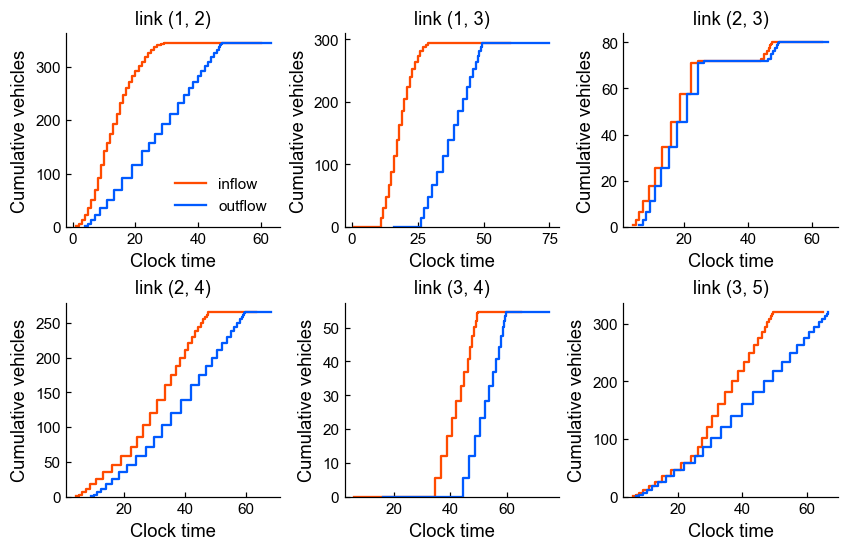

In [6]:
fig = plot_cumulative_curves(net, res)

## 6. Queue delays by departure step

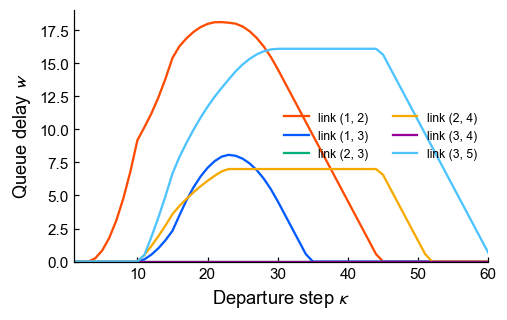

In [7]:
fig = plot_queue_delays(net, res)

## 7. Route-choice equilibrium per OD pair (paper Figs. 3, 4)

Upper panel: travel time of every route for each departure step (used or not).
Lower band: departure steps on which the route carries inflow. At a DUE, every route that
carries inflow has the minimum travel time among the routes of its OD pair.

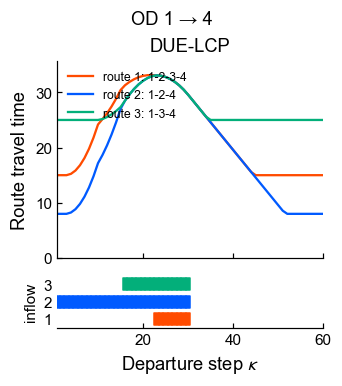

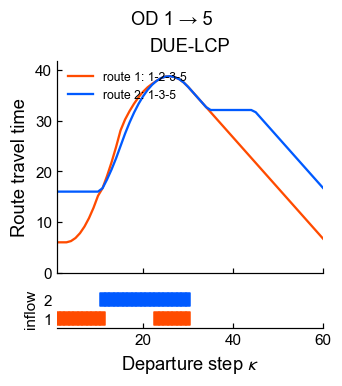

In [8]:
for d in net.destinations:
    fig = plot_route_equilibrium(net, res, d)